<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_6_(Exercise_6_1)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Imports and Random Sequence

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

n_positions = 10
d           = 64

# A sequence of 10 random vectors, each dimension 64
x = torch.randn(n_positions, d)
print(f"Input sequence shape: {x.shape}")

Input sequence shape: torch.Size([10, 64])


In [2]:
# Raw Scaled Dot-Product Attention

def scaled_dot_product_attention(Q, K, V):
    """
    Q, K, V: (n, d)
    Returns: output (n, d), attention_weights (n, n)
    """
    d_k     = Q.shape[-1]
    scores  = Q @ K.T / np.sqrt(d_k)        # (n, n) raw match scores
    weights = F.softmax(scores, dim=-1)     # (n, n) each row sums to 1
    output  = weights @ V                   # (n, d) weighted blend of values
    return output, weights


# With no learnable projections, Q = K = V = x directly
output, attn_weights = scaled_dot_product_attention(x, x, x)

print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")
print(f"Each row sums to: {attn_weights.sum(dim=-1)}")  # should all be ~1.0

Output shape: torch.Size([10, 64])
Attention weights shape: torch.Size([10, 10])
Each row sums to: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])


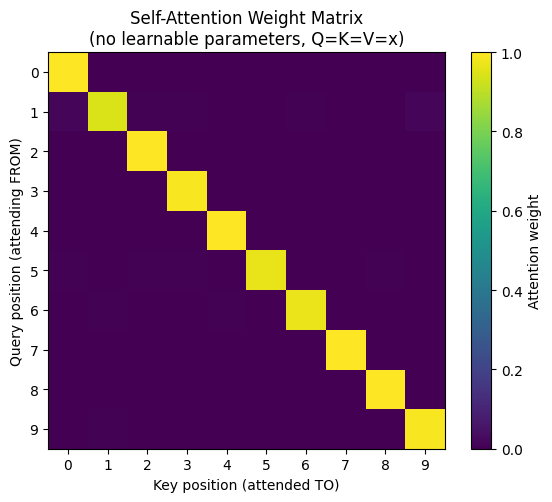

In [3]:
# Visualisation 1: The Attention Heatmap

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(attn_weights.detach().numpy(), cmap='viridis', vmin=0, vmax=1)
ax.set_xlabel('Key position (attended TO)')
ax.set_ylabel('Query position (attending FROM)')
ax.set_title('Self-Attention Weight Matrix\n(no learnable parameters, Q=K=V=x)')
ax.set_xticks(range(n_positions))
ax.set_yticks(range(n_positions))
plt.colorbar(im, ax=ax, label='Attention weight')

plt.tight_layout()
plt.savefig('attn_heatmap_6_1.png', dpi=150)
plt.show()

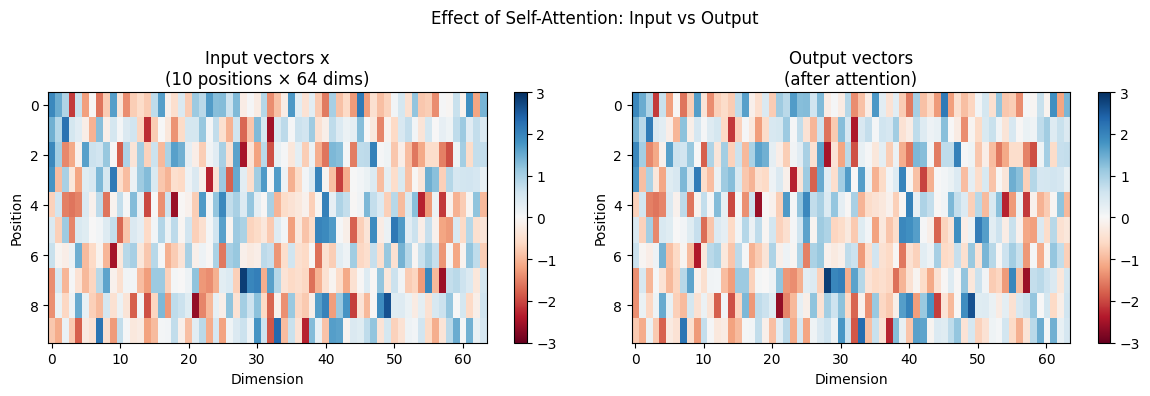

In [4]:
# Visualisation 2: Input vs Output Heatmaps Side By Side

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(x.detach().numpy(), cmap='RdBu', aspect='auto',
                     vmin=-3, vmax=3)
axes[0].set_title('Input vectors x\n(10 positions × 64 dims)')
axes[0].set_xlabel('Dimension')
axes[0].set_ylabel('Position')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(output.detach().numpy(), cmap='RdBu', aspect='auto',
                     vmin=-3, vmax=3)
axes[1].set_title('Output vectors\n(after attention)')
axes[1].set_xlabel('Dimension')
axes[1].set_ylabel('Position')
plt.colorbar(im1, ax=axes[1])

plt.suptitle('Effect of Self-Attention: Input vs Output')
plt.tight_layout()
plt.savefig('attn_io_6_1.png', dpi=150)
plt.show()

In [5]:
# Learnable Attention Module

class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.d_model = d_model

    def forward(self, x):
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        scores  = Q @ K.transpose(-2, -1) / np.sqrt(self.d_model)
        weights = F.softmax(scores, dim=-1)
        output  = weights @ V
        return output, weights

In [6]:
#  Sequence Reconstruction Task

torch.manual_seed(0)

# A FIXED target sequence — attention must learn to reconstruct this specific one
target_seq = torch.randn(n_positions, d)

model     = SelfAttention(d_model=d)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

n_iterations    = 2000
saved_weights   = []   # store attention matrix every 100 iters
saved_iters     = []
loss_history    = []

for it in range(n_iterations):
    noisy_input = target_seq + 0.5 * torch.randn_like(target_seq)

    optimizer.zero_grad()
    output, weights = model(noisy_input)
    loss = F.mse_loss(output, target_seq)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if it % 100 == 0:
        saved_weights.append(weights.detach().numpy().copy())
        saved_iters.append(it)
        print(f"Iter {it:>4} | Loss: {loss.item():.4f}")

print("Training complete.")

Iter    0 | Loss: 1.0829
Iter  100 | Loss: 0.0805
Iter  200 | Loss: 0.0739
Iter  300 | Loss: 0.0558
Iter  400 | Loss: 0.0806
Iter  500 | Loss: 0.0797
Iter  600 | Loss: 0.0797
Iter  700 | Loss: 0.0626
Iter  800 | Loss: 0.0847
Iter  900 | Loss: 0.0565
Iter 1000 | Loss: 0.0804
Iter 1100 | Loss: 0.0474
Iter 1200 | Loss: 0.0921
Iter 1300 | Loss: 0.0725
Iter 1400 | Loss: 0.0577
Iter 1500 | Loss: 0.0798
Iter 1600 | Loss: 0.0719
Iter 1700 | Loss: 0.0646
Iter 1800 | Loss: 0.0448
Iter 1900 | Loss: 0.0878
Training complete.


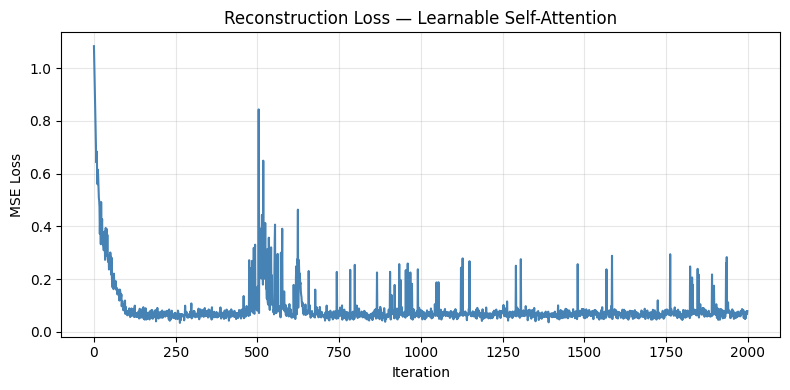

In [7]:
# Loss Curve

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color='steelblue')
ax.set_xlabel('Iteration')
ax.set_ylabel('MSE Loss')
ax.set_title('Reconstruction Loss — Learnable Self-Attention')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('attn_loss_6_1.png', dpi=150)
plt.show()

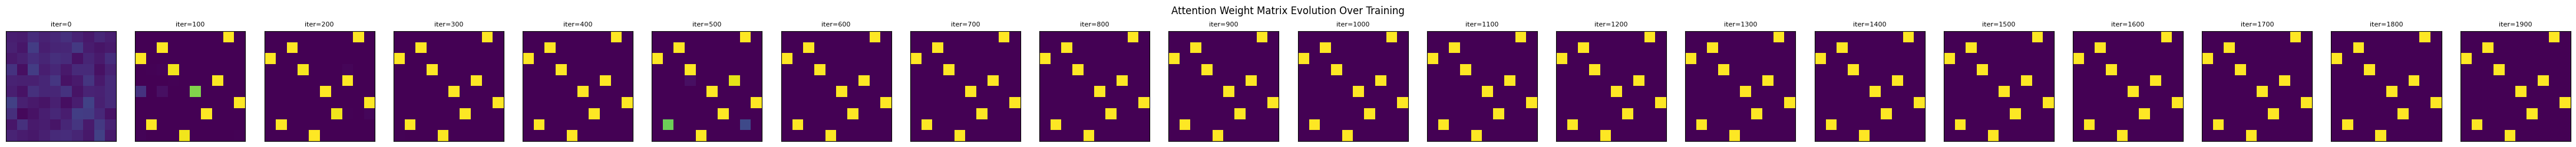

In [8]:
# Animate Attention Pattern Evolution

n_snapshots = len(saved_weights)
fig, axes   = plt.subplots(1, n_snapshots, figsize=(2.2 * n_snapshots, 2.5))

for i, (w, it) in enumerate(zip(saved_weights, saved_iters)):
    im = axes[i].imshow(w, cmap='viridis', vmin=0, vmax=1)
    axes[i].set_title(f'iter={it}', fontsize=8)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

plt.suptitle('Attention Weight Matrix Evolution Over Training', fontsize=12)
plt.tight_layout()
plt.savefig('attn_evolution_6_1.png', dpi=150)
plt.show()

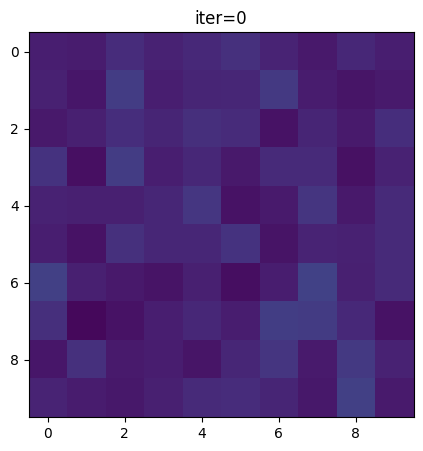

In [9]:
# Actual animated GIF rather than static strip of snapshots.

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(saved_weights[0], cmap='viridis', vmin=0, vmax=1)
title = ax.set_title(f'iter={saved_iters[0]}')

def update(frame):
    im.set_data(saved_weights[frame])
    title.set_text(f'iter={saved_iters[frame]}')
    return [im, title]

anim = FuncAnimation(fig, update, frames=n_snapshots, interval=300)
anim.save('attn_evolution_6_1.gif', writer='pillow')
HTML(anim.to_jshtml())

# Interpretation And Observation

#### The no-parameter attention matrix collapsed to a near-perfect diagonal rather than a soft, distributed pattern, because in 64 dimensions a random vector's dot product with itself is far larger than its dot product with any other independent random vector, and softmax exponentially amplifies that gap into almost pure self-attention. This made the output of unparameterized attention nearly identical to the input, since each position effectively just returned its own value vector with negligible contribution from anywhere else. Once Q, K and V became learnable and the model was trained to denoise a fixed target sequence from freshly resampled noise at every iteration, the attention pattern evolved away from anything content-adaptive and instead converged on a fixed permutation, where each query position learned to consistently attend to one specific other position regardless of the current noise realization, with the corresponding value vector trained to directly supply the correct piece of the fixed target. This explains the periodic spikes visible in the loss curve: because Q and K are computed directly from the noisy input each step, occasional large noise draws are enough to momentarily disrupt which key receives the highest score, breaking the learned permutation until gradient descent restores it. This result foreshadows exactly why LDAE's semantic encoder cannot rely on a single fixed attention pattern the way this toy task did — Exercise 6.2's soft-attention pooling must remain genuinely content-adaptive across real, varying MRI slices rather than collapsing onto a shortcut that only works because the target never changes.